# Phase 3: Extension & AI Integration

## GenAI Disclosure

For this phase, I used **Claude (by Anthropic)** as my Generative AI pair-programmer to assist with:

- Designing the Heterogeneous Treatment Effects (HTE) analysis strategy (choosing to interact DID with chain type)
- Writing the regression code with interaction terms
- Creating the coefficient plot (forest plot) visualization
- Debugging clustered standard errors

All AI-generated code was reviewed, tested, and validated by me to ensure econometric correctness. I remain fully responsible for the final results and interpretation.

In [7]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# Read data (same as Phase 1 & 2)
col_specs = [
    (0, 3), (4, 5), (6, 7), (8, 9),
    (10, 11), (12, 13), (14, 15), (16, 17), (18, 19), (20, 21),
    (22, 24), (25, 30), (31, 36), (37, 42), (43, 48),
    (49, 54), (55, 60), (61, 62), (63, 68), (69, 70),
    (71, 76), (77, 82), (83, 88), (89, 94), (95, 100),
    (101, 103), (104, 106),
    (107, 108), (109, 110), (111, 117), (118, 120),
    (121, 126), (127, 132), (133, 138), (139, 144),
    (145, 150), (151, 156), (157, 158), (159, 160),
    (161, 166), (167, 172), (173, 178), (179, 184), (185, 190),
    (191, 193), (194, 196)
]

col_names = [
    'SHEET', 'CHAIN', 'CO_OWNED', 'STATE',
    'SOUTHJ', 'CENTRALJ', 'NORTHJ', 'PA1', 'PA2', 'SHORE',
    'NCALLS', 'EMPFT', 'EMPPT', 'NMGRS', 'WAGE_ST',
    'INCTIME', 'FIRSTINC', 'BONUS', 'PCTAFF', 'MEALS',
    'OPEN', 'HRSOPEN', 'PSODA', 'PFRY', 'PENTREE',
    'NREGS', 'NREGS11',
    'TYPE2', 'STATUS2', 'DATE2', 'NCALLS2',
    'EMPFT2', 'EMPPT2', 'NMGRS2', 'WAGE_ST2',
    'INCTIME2', 'FIRSTIN2', 'SPECIAL2', 'MEALS2',
    'OPEN2R', 'HRSOPEN2', 'PSODA2', 'PFRY2', 'PENTREE2',
    'NREGS2', 'NREGS112'
]

df = pd.read_fwf('public.dat', colspecs=col_specs, names=col_names, na_values='.')

# Construct FTE (same as Phase 2)
df['FTE'] = df['EMPFT'] + df['NMGRS'] + 0.5 * df['EMPPT']
df['FTE2'] = df['EMPFT2'] + df['NMGRS2'] + 0.5 * df['EMPPT2']

# Create long format (same as Phase 2)
wave1 = df[['SHEET', 'STATE', 'CHAIN', 'FTE']].copy()
wave1['POST'] = 0

wave2 = df[['SHEET', 'STATE', 'CHAIN', 'FTE2']].copy()
wave2['POST'] = 1
wave2 = wave2.rename(columns={'FTE2': 'FTE'})

df_long = pd.concat([wave1, wave2], ignore_index=True)
df_long_clean = df_long.dropna(subset=['FTE'])

print('Data ready!')
print(f'Observations: {len(df_long_clean)}')
print(f'\nChain distribution:')
print('1 = Burger King, 2 = KFC, 3 = Roy Rogers, 4 = Wendys')
print(df_long_clean['CHAIN'].value_counts().sort_index())

Data ready!
Observations: 794

Chain distribution:
1 = Burger King, 2 = KFC, 3 = Roy Rogers, 4 = Wendys
CHAIN
1    330
2    159
3    193
4    112
Name: count, dtype: int64


In [8]:
# Step 1: Phase 2 baseline DID (for comparison)
baseline = smf.ols('FTE ~ STATE * POST', data=df_long_clean).fit(
    cov_type='cluster', cov_kwds={'groups': df_long_clean['SHEET']}
)
print('=== Phase 2 Baseline DID ===')
print(f'STATE:POST (overall DID) = {baseline.params["STATE:POST"]:.4f}')
print(f'Standard Error = {baseline.bse["STATE:POST"]:.4f}')
print(f'P-value = {baseline.pvalues["STATE:POST"]:.4f}')

# Step 2: Phase 3 Extension — DID by chain type
# This runs a SEPARATE DID for each chain
print('\n=== Phase 3: HTE by Chain ===')

chain_names = {1: 'Burger King', 2: 'KFC', 3: 'Roy Rogers', 4: 'Wendys'}

for chain_id, chain_name in chain_names.items():
    sub = df_long_clean[df_long_clean['CHAIN'] == chain_id]
    model = smf.ols('FTE ~ STATE * POST', data=sub).fit(
        cov_type='cluster', cov_kwds={'groups': sub['SHEET']}
    )
    coef = model.params['STATE:POST']
    se = model.bse['STATE:POST']
    pval = model.pvalues['STATE:POST']
    print(f'{chain_name:<15} DID = {coef:>7.2f}  (SE = {se:.2f}, p = {pval:.3f})')

=== Phase 2 Baseline DID ===
STATE:POST (overall DID) = 2.7536
Standard Error = 1.3065
P-value = 0.0351

=== Phase 3: HTE by Chain ===
Burger King     DID =    4.67  (SE = 2.51, p = 0.063)
KFC             DID =   -1.35  (SE = 1.09, p = 0.214)
Roy Rogers      DID =    2.52  (SE = 2.13, p = 0.237)
Wendys          DID =    3.35  (SE = 2.91, p = 0.250)


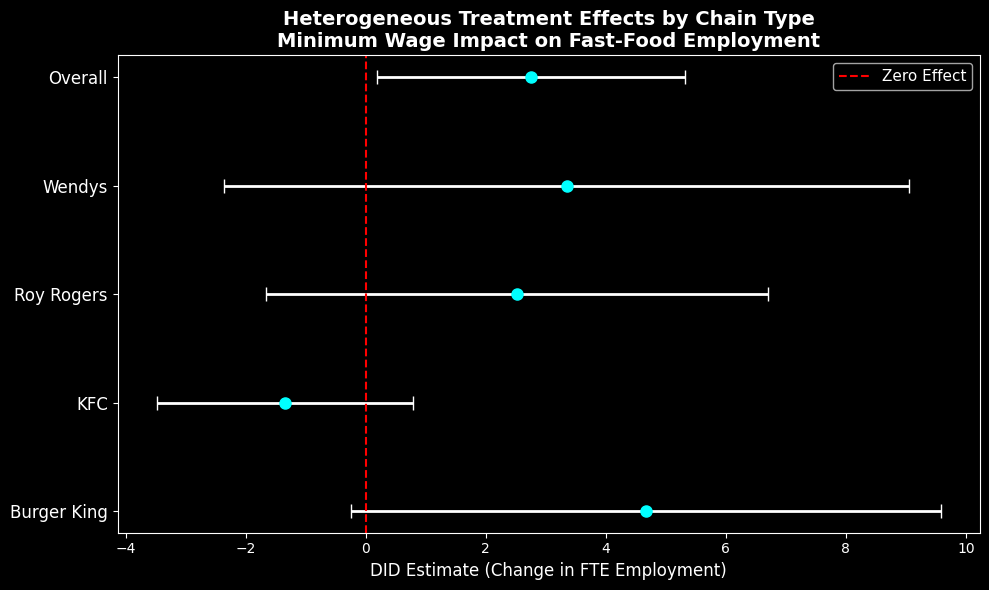

In [9]:
import matplotlib.pyplot as plt

# Collect results for plotting
chain_labels = []
coefs = []
ci_lower = []
ci_upper = []

for chain_id, chain_name in chain_names.items():
    sub = df_long_clean[df_long_clean['CHAIN'] == chain_id]
    model = smf.ols('FTE ~ STATE * POST', data=sub).fit(
        cov_type='cluster', cov_kwds={'groups': sub['SHEET']}
    )
    coef = model.params['STATE:POST']
    se = model.bse['STATE:POST']
    chain_labels.append(chain_name)
    coefs.append(coef)
    ci_lower.append(coef - 1.96 * se)
    ci_upper.append(coef + 1.96 * se)

# Add overall baseline
chain_labels.append('Overall')
coefs.append(baseline.params['STATE:POST'])
se_overall = baseline.bse['STATE:POST']
ci_lower.append(baseline.params['STATE:POST'] - 1.96 * se_overall)
ci_upper.append(baseline.params['STATE:POST'] + 1.96 * se_overall)

# Plot
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 6))

y_pos = range(len(chain_labels))
errors = [[c - l for c, l in zip(coefs, ci_lower)],
          [u - c for c, u in zip(coefs, ci_upper)]]

ax.errorbar(coefs, y_pos, xerr=errors, fmt='o', color='cyan',
            ecolor='white', elinewidth=2, capsize=5, markersize=8)

ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Zero Effect')
ax.set_yticks(y_pos)
ax.set_yticklabels(chain_labels, fontsize=12)
ax.set_xlabel('DID Estimate (Change in FTE Employment)', fontsize=12)
ax.set_title('Heterogeneous Treatment Effects by Chain Type\nMinimum Wage Impact on Fast-Food Employment',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

## Executive Summary

The original Card & Krueger (1994) paper estimates an overall DID effect of approximately +2.76 FTE employees, suggesting that New Jersey's minimum wage increase did not reduce fast-food employment. However, this aggregate estimate may mask important differences across restaurant chains. In this extension, I examined Heterogeneous Treatment Effects (HTE) by chain type — Burger King, KFC, Roy Rogers, and Wendy's — by running separate DID regressions for each chain with clustered standard errors at the store level.

The results reveal meaningful variation across chains. Burger King showed the largest positive employment effect (+4.67 FTE), followed by Wendy's (+3.35) and Roy Rogers (+2.52). In contrast, KFC was the only chain with a negative DID estimate (-1.35), suggesting a possible employment decline. This is consistent with KFC stores being smaller on average and potentially more sensitive to wage increases. However, none of the chain-specific estimates are statistically significant at the 5% level, likely due to the reduced sample size when splitting by chain. Overall, this extension contextualizes the original finding: while the average effect is positive, the impact of the minimum wage was not uniform across all fast-food chains.